In [1]:
import numpy as np
import os

In [2]:
data = np.load("dataset_velocity_4.0.npy", allow_pickle=True)

In [14]:
for datapoint in filtered_data:
    if len(datapoint) != 10:
        print(datapoint)
        raise ValueError("Each datapoint must have 3 elements, "
                         "the second element must be a list of 2 points, "
                         "and each point must be a list of 4 values.")

In [8]:
false_data = []
for i in range(len(data)):
    if data[i][2] ==False:
        false_data.append(data[i])
print("Total number of false data points:", len(false_data))
print("Total number of data points:", len(data))

Total number of false data points: 26
Total number of data points: 707


In [9]:
filtered_data

[[1.4759561382234097,
  0.0,
  0.0,
  0.0,
  0.0010562428229651207,
  1.4651606460192111e-05,
  1.0333842770148069e-05,
  0.0031687893220245763,
  3.9178568367561555e-05,
  2.7617420061951426e-05,
  'true'],
 [1.5759561397135258,
  0.0,
  0.0,
  0.0,
  0.0010563378062441358,
  3.742958257615484e-06,
  2.6399249962463582e-06,
  0.003169015167258323,
  1.0717971296755781e-05,
  7.555498808534279e-06,
  'true'],
 [1.675956141203642,
  2.3012935554627113e-08,
  5.1039056117193615e-11,
  3.5998071780377806e-11,
  0.001056354874476545,
  8.671195867587619e-06,
  6.115832729695048e-06,
  0.0031690135608844804,
  2.3664407947295464e-05,
  1.6681498448752208e-05,
  'true'],
 [1.775956142693758,
  9.584455608651157e-06,
  3.092975136678279e-08,
  2.181489029291842e-08,
  0.0010754073739619838,
  1.5064833751626684e-05,
  1.0625277405619969e-05,
  0.003197524663422568,
  4.0804130833929165e-05,
  2.8763414094294853e-05,
  'true'],
 [1.8759561441838741,
  5.423517662088615e-06,
  1.841154772420389

In [15]:
text_file = ""
for datapoint in filtered_data:
    points = ",".join([str(p) for p in datapoint])
    text_file += f"{points}\n"
with open("dataset/dataset.data", "w") as f:
    f.write(text_file)
print("Data saved to 'dataset/dataset.data'.")

Data saved to 'dataset/dataset.data'.


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import PolynomialFeatures

In [11]:
def filter_data(data):
    filtered_data = []
    for datapoint in data:
        try:
            time = float(datapoint[0])
            traj = []
            for p in datapoint[1][2:4]:
                traj.append(float(p[0]))
                traj.append(float(p[1]))
                traj.append(np.cos(float(p[2])))
                traj.append(np.sin(float(p[2])))
            class_ = bool(datapoint[2])
            class_ = "true" if class_ else "false"
            filtered_data.append([time, *traj, class_])
        except (ValueError, TypeError):
            print(f"Invalid data point: {datapoint}")
            continue
    return filtered_data

In [12]:
filtered_data = filter_data(data)

Invalid data point: ['timestamp' 'safe_spaces' 'safety_check']
Invalid data point: ['timestamp' 'safe_spaces' 'safety_check']
Invalid data point: ['timestamp' 'safe_spaces' 'safety_check']
Invalid data point: ['timestamp' 'safe_spaces' 'safety_check']
Invalid data point: ['timestamp' 'safe_spaces' 'safety_check']


In [48]:
X = []
y = []
for datapoint in filtered_data:
    x = [float(datapoint[0])]
    x.extend(datapoint[1])
    X.append(x)
    y.append(datapoint[2])


In [60]:
features = PolynomialFeatures(degree=1, include_bias=True)
X = features.fit_transform(X)

In [65]:
X

array([[1.00000000e+00, 1.47595614e+00, 0.00000000e+00, ...,
        5.92544554e-01, 8.71851319e-03, 5.06904498e-03],
       [1.00000000e+00, 1.57595614e+00, 0.00000000e+00, ...,
        5.23936816e-01, 3.07397706e-03, 1.88610032e-03],
       [1.00000000e+00, 1.67595614e+00, 2.30129356e-08, ...,
        5.57718292e-01, 5.92683351e-03, 3.54482113e-03],
       ...,
       [1.00000000e+00, 6.48071633e+01, 1.79301888e-01, ...,
        5.11011131e+00, 5.13814148e-02, 3.60712090e-02],
       [1.00000000e+00, 6.49071633e+01, 1.86367084e-01, ...,
        4.92137852e+00, 5.74060399e-02, 3.34877688e-02],
       [1.00000000e+00, 6.50071633e+01, 1.83422117e-01, ...,
        4.85481057e+00, 5.92932267e-02, 3.31450605e-02]])

In [61]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1)
clf.fit(X, y)


DecisionTreeClassifier()

In [63]:
for datapoint in filtered_data:
    x = [float(datapoint[0])]
    x.extend(datapoint[1])
    x = features.transform([x])[0]
    prediction = clf.predict([x])
    ground_truth = datapoint[2]
    if prediction != ground_truth:
        print(f"Discrepancy found: Predicted {prediction}, Ground Truth {ground_truth} for datapoint {datapoint}")

[Text(0.5, 0.9, 'x[33] <= 0.007\ngini = 0.071\nsamples = 702\nvalue = [26, 676]'),
 Text(0.3333333333333333, 0.7, 'x[89] <= 5.688\ngini = 0.034\nsamples = 688\nvalue = [12, 676]'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 636\nvalue = [0, 636]'),
 Text(0.5, 0.5, 'x[1] <= 39.107\ngini = 0.355\nsamples = 52\nvalue = [12, 40]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 26\nvalue = [0, 26]'),
 Text(0.6666666666666666, 0.3, 'x[1] <= 46.007\ngini = 0.497\nsamples = 26\nvalue = [12, 14]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.8333333333333334, 0.1, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.6666666666666666, 0.7, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.5833333333333333, 0.8, '  False')]

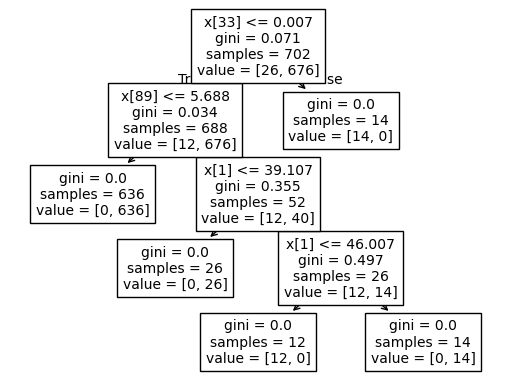

In [64]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(clf)